<a href="https://colab.research.google.com/github/jenianggraeni265-a11y/Machine-Learning-Pre-Processing/blob/main/PRE_PROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Netflix Data Preprocessing & Exploratory Data Analysis (EDA)**

Dataset ini berisi informasi film dan TV show yang tersedia di Netflix, mencakup atribut seperti judul, sutradara, negara asal, tahun rilis, durasi, dan genre.

Dataset ini memiliki berbagai permasalahan kualitas data seperti missing values, inkonsistensi format, dan variabel kategorikal yang kompleks, sehingga sangat cocok untuk proses data preprocessing.

### **1. Import Library dan Load Dataset**

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Library pandas digunakan untuk mengelola dan memanipulasi data dalam bentuk tabel (DataFrame), sedangkan matplotlib.pyplot digunakan untuk membuat visualisasi data seperti grafik.

Dataset dibaca menggunakan fungsi read_csv() dan disimpan dalam variabel df. Fungsi head() digunakan untuk menampilkan lima baris pertama guna memahami struktur awal data.

### **2. Melihat Struktur Data**

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Fungsi info() digunakan untuk melihat informasi umum dataset, seperti jumlah baris, nama kolom, tipe data, serta jumlah nilai yang tidak kosong. Langkah ini penting untuk mengidentifikasi adanya missing values.

### **3. Statistik Deskriptif**

In [119]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Fungsi describe() digunakan untuk menampilkan ringkasan statistik dari variabel numerik, seperti nilai rata-rata, minimum, maksimum, dan standar deviasi.

### **4. Cek Missing Values**

In [120]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Digunakan untuk menghitung jumlah nilai yang hilang pada setiap kolom. Hasil ini menjadi dasar dalam menentukan metode penanganan missing values.

### **5. Handling Missing Values**

In [121]:
# Mengisi missing dengan 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')


# Drop kalau date_added kosong
df = df.dropna(subset=['date_added'])

Missing values pada variabel kategorikal seperti director, cast, dan country ditangani dengan mengganti nilai kosong menjadi "Unknown" untuk mempertahankan jumlah observasi tanpa menghilangkan informasi.

Sementara itu, baris dengan nilai kosong pada kolom date_added dihapus karena kolom tersebut penting untuk analisis waktu.

### **6. Cek dan Hapus Duplikasi**

In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
df = df.drop_duplicates()

Fungsi duplicated() digunakan untuk mendeteksi data yang sama (duplikat), kemudian dihapus menggunakan drop_duplicates() agar tidak mempengaruhi hasil analisis.

### **7. Transformasi Tanggal**

In [124]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

Kolom date_added diubah menjadi format datetime agar dapat diolah lebih lanjut. Dari kolom tersebut kemudian diekstrak informasi tambahan berupa tahun dan bulan.

### **8. Transformasi Genre**

In [125]:
df['listed_in'] = df['listed_in'].str.split(',')

Kolom listed_in yang berisi beberapa genre dalam satu string dipisahkan menjadi bentuk list agar setiap genre dapat dianalisis secara terpisah.

### **9. Encoding Variabel**

In [126]:
df['type'] = df['type'].map({'Movie':0, 'TV Show':1})

Pada tahap ini dilakukan proses encoding variabel kategorikal pada kolom type. Nilai kategorikal:

    Movie diubah menjadi 0
    TV Show diubah menjadi 1

Tujuan dari encoding ini adalah untuk mengubah data kategorikal menjadi bentuk numerik agar dapat digunakan dalam analisis statistik maupun pemodelan machine learning.

In [127]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   int64         
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8793 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
 12  year_added    8797 non-null   int32         
 13  month_added   8797 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(2), object(9)
memory usage: 962.2+ KB


Output df.info() memberikan informasi mengenai:

    jumlah data (baris) sebanyak 8797 data
    jumlah variabel (kolom) sebanyak 14 variabel
    tipe data tiap kolom
    jumlah data yang tidak kosong (non-null)

Proses encoding pada variabel type berhasil mengubah data kategorikal menjadi numerik, yang ditunjukkan dengan perubahan tipe data dari object menjadi int64. Hal ini memungkinkan variabel tersebut digunakan dalam analisis kuantitatif.

Berdasarkan output df.info(), dataset terdiri dari 8797 observasi dan 14 variabel dengan berbagai tipe data, termasuk numerik, kategorikal, dan datetime. Sebagian besar data telah bersih, meskipun masih terdapat sedikit missing values pada kolom rating dan duration. Secara keseluruhan, dataset telah berada dalam kondisi yang siap untuk tahap analisis lebih lanjut.

### **Tren Konten per Tahun**

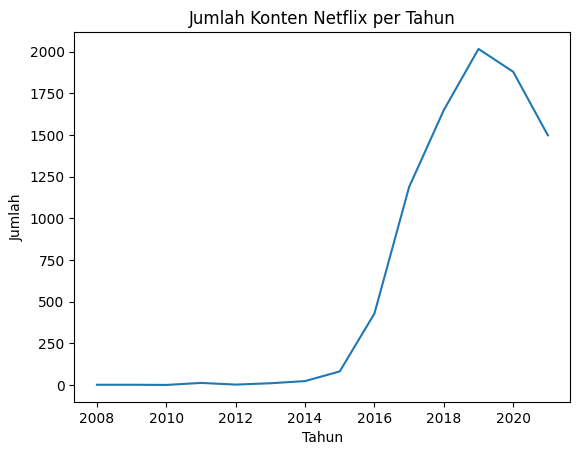

In [128]:
import matplotlib.pyplot as plt

df['year_added'].value_counts().sort_index().plot()

plt.title('Jumlah Konten Netflix per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah')
plt.show()

Grafik ini menggambarkan jumlah konten yang ditambahkan setiap tahun, sehingga dapat digunakan untuk melihat tren pertumbuhan konten.

### **Distribusi Tipe Konten**

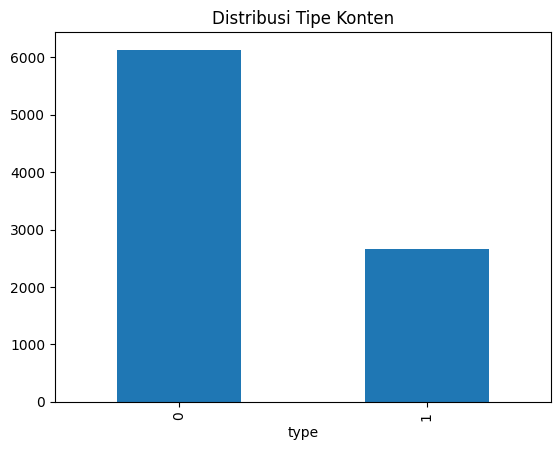

In [129]:
df['type'].value_counts().plot(kind='bar')
plt.title('Distribusi Tipe Konten')
plt.show()

### **Top 10 Negara Produksi**

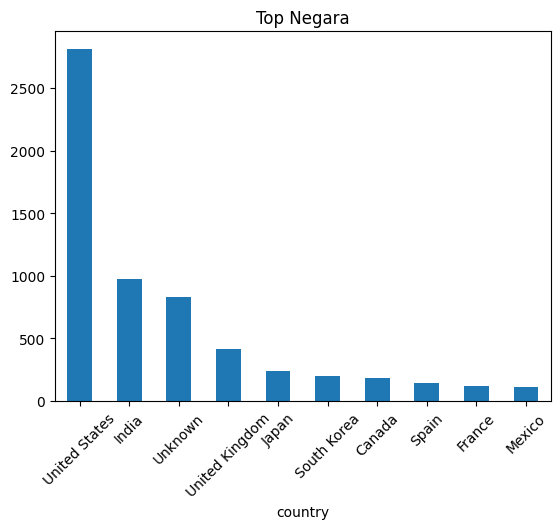

In [130]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Negara')
plt.xticks(rotation=45)
plt.show()

Grafik menampilkan 10 negara dengan jumlah produksi konten terbanyak.

### **Distribusi Rating**

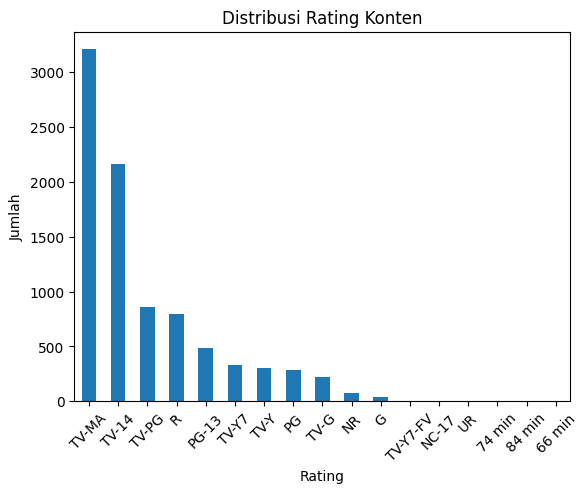

In [131]:
df['rating'].value_counts().plot(kind='bar')

plt.title('Distribusi Rating Konten')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

Menunjukkan distribusi kategori rating konten, yang mencerminkan segmentasi usia target penonton.

### **Genre Paling Populer**

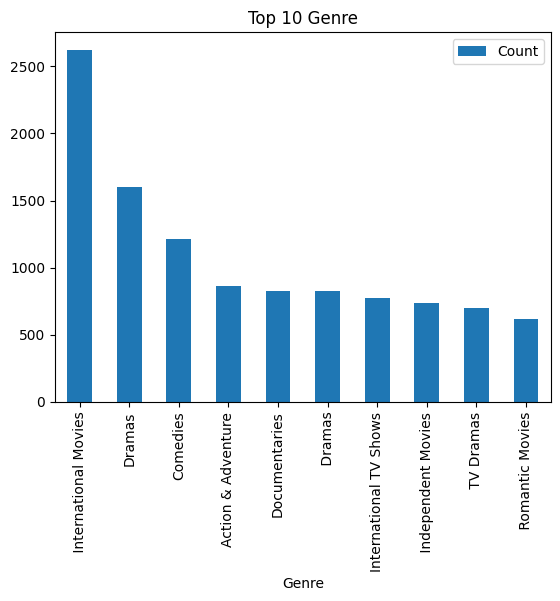

In [132]:
from collections import Counter

# Gabungkan semua genre
genres = df['listed_in'].explode()

top_genres = Counter(genres).most_common(10)

genre_df = pd.DataFrame(top_genres, columns=['Genre', 'Count'])

genre_df.plot(x='Genre', y='Count', kind='bar')

plt.title('Top 10 Genre')
plt.xticks(rotation=90)
plt.show()

Pada tahap preprocessing, dilakukan beberapa langkah untuk meningkatkan kualitas data. Pertama, dilakukan identifikasi missing values yang ditemukan pada beberapa kolom seperti director, cast, dan country. Missing values tersebut ditangani dengan mengganti nilai kosong menjadi "Unknown" untuk mempertahankan informasi data.

Selanjutnya, dilakukan penghapusan data pada kolom date_added yang memiliki nilai kosong karena kolom tersebut penting untuk analisis temporal. Selain itu, dilakukan pengecekan dan penghapusan data duplikat untuk menjaga konsistensi dataset.

Transformasi data juga dilakukan dengan mengubah format tanggal menjadi tipe datetime, sehingga memungkinkan ekstraksi informasi tambahan seperti tahun dan bulan. Variabel kategorikal seperti type juga dikonversi menjadi bentuk numerik untuk memudahkan analisis lebih lanjut.